<a href="https://colab.research.google.com/github/RajeshRanaGiet/AML-LAB/blob/main/Practice/Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
def train_and_evaluate(X, y, title):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)
    equation = f"y = {model.intercept_:.4f}"
    for coef, col in zip(model.coef_, X.columns):
        equation += f" + {coef:.4f} * {col}"
    print(f"\n--- {title} ---")
    print(f"Equation: {equation}")
    print(f"MSE: {mse:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")
    return model, X_test, y_test, predictions, [mae, mse, rmse, r2]

def plot_chart(chart_type, x_data, y_data, title, xlabel, ylabel, predictions=None):
    if chart_type == 'scatter_line':
        plt.scatter(x_data, y_data, color='blue', label='Actual Marks')
        plt.plot(x_data, predictions, color='red', linewidth=2, label='Regression Line')
        plt.legend()
    elif chart_type == 'actual_vs_pred':
        plt.scatter(x_data, y_data, color='purple', label='Predictions')
        plt.plot([x_data.min(), x_data.max()], [x_data.min(), x_data.max()], 'r--', label='Ideal Fit')
        plt.legend()
    elif chart_type == 'metrics_bar':
        bars = plt.barh(["MAE", "MSE", "RMSE", "R2"], x_data, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'])
        for bar in bars:
            width = bar.get_width()
            plt.annotate(f"{width:.4f}", xy=(width, bar.get_y() + bar.get_height() / 2), ha="left", va="center", fontweight="bold")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()

--- Dataset Summary ---
Shape :  (100, 3)

Missing Values :
 number_courses    0
time_study        0
Marks             0
dtype: int64

Stats :
        number_courses  time_study       Marks
count      100.000000  100.000000  100.000000
mean         5.290000    4.077140   24.417690
std          1.799523    2.372914   14.326199
min          3.000000    0.096000    5.609000
25%          4.000000    2.058500   12.633000
50%          5.000000    4.022000   20.059500
75%          7.000000    6.179250   36.676250
max          8.000000    7.957000   55.299000


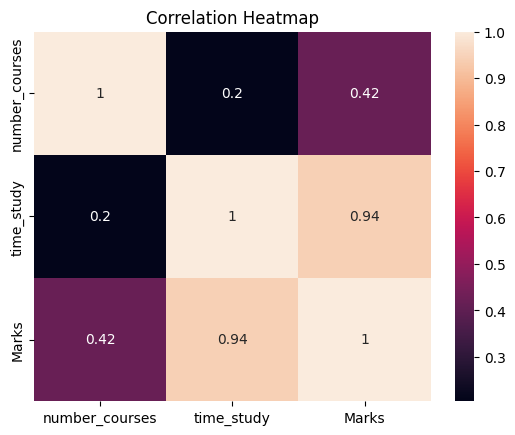

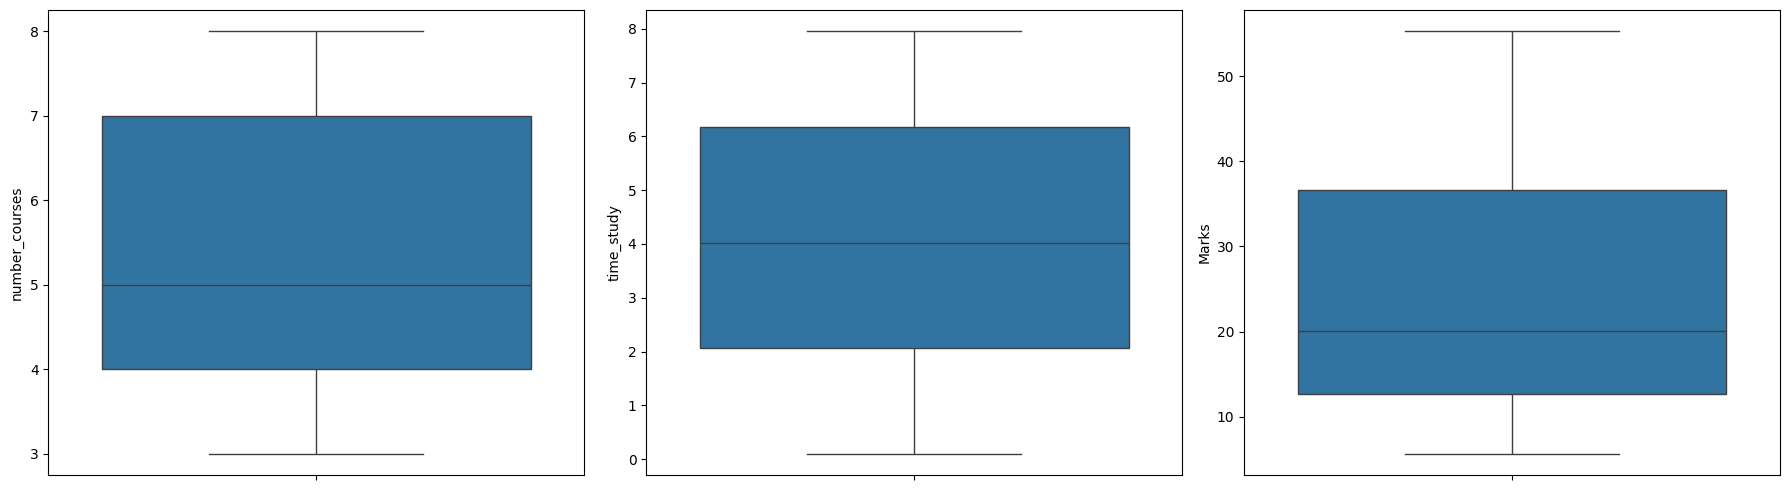


Top correlated feature with SEM 5 is: 'time_study'

--- Simple Linear Regression ---
Equation: y = 2.5156 + 5.3553 * time_study
MSE: 25.2367 | MAE: 3.9690 | RMSE: 5.0236 | R²: 0.9040


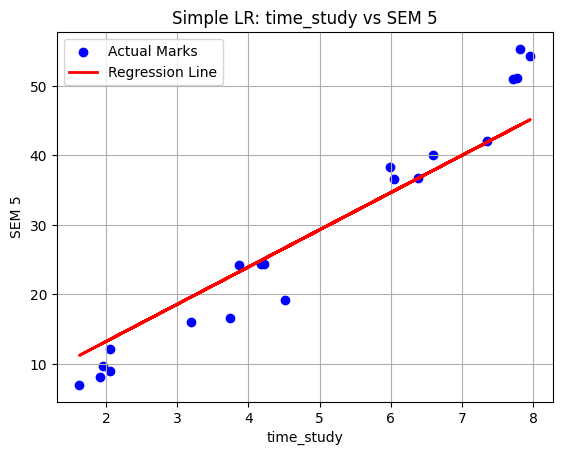

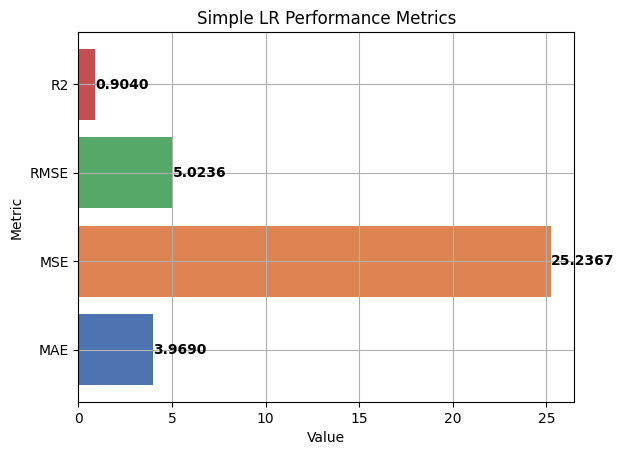


--- Multiple Linear Regression ---
Equation: y = -6.6130 + 1.8715 * number_courses + 5.1699 * time_study
MSE: 14.2007 | MAE: 3.0793 | RMSE: 3.7684 | R²: 0.9460


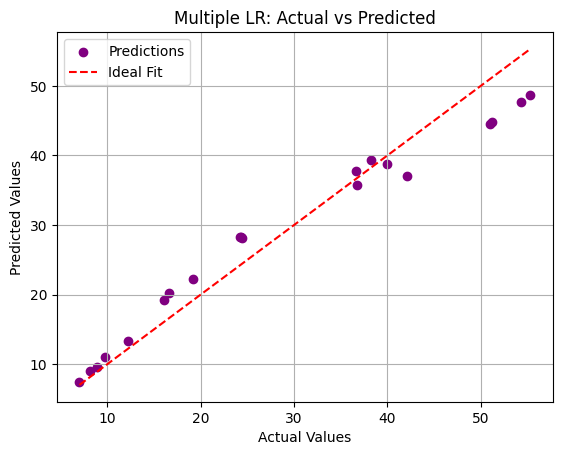

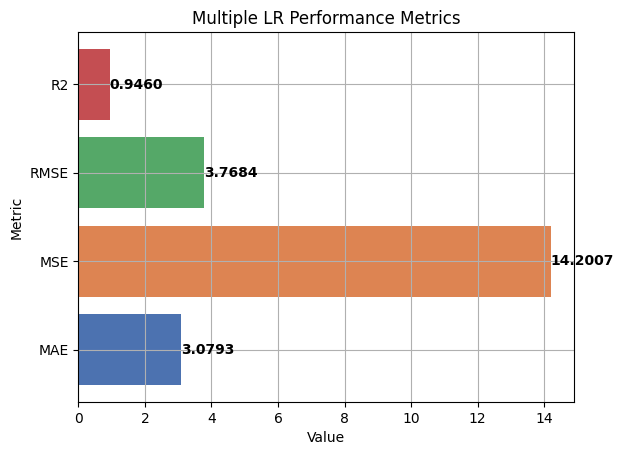


--- Enter Marks to Predict SEM 5 ---
Enter number of courses : 3
Enter time spent studying : 4

The predicted 5th Semester mark is: 19.68


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


data = pd.read_csv("https://raw.githubusercontent.com/RajeshRanaGiet/AML-LAB/main/Practice/Student_Marks.csv")
print("--- Dataset Summary ---")
print("Shape : ", data.shape)
print("\nMissing Values :\n", data.isnull().sum())
print("\nStats :\n", data.describe())

features = ["number_courses", "time_study"]
x_all = data[features]
y = data["Marks"]

sns.heatmap(data.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

fig, axes = plt.subplots(1, len(data.columns), figsize=(18, 5))
for i, col in enumerate(data.columns):
  sns.boxplot(y=data[col], ax=axes[i])
plt.tight_layout()
plt.show()

best_feature = x_all.corrwith(y).abs().idxmax()
print(f"\nTop correlated feature with SEM 5 is: '{best_feature}'")

X_simple = data[[best_feature]]

simple_model, X_test_s, y_test_s, pred_s, metrics_s = train_and_evaluate(X_simple, y, 'Simple Linear Regression')

plot_chart('scatter_line', X_test_s, y_test_s, f'Simple LR: {best_feature} vs SEM 5', best_feature, 'SEM 5', pred_s)
plot_chart('metrics_bar', metrics_s, None, 'Simple LR Performance Metrics', 'Value', 'Metric')

multi_model, X_test_m, y_test_m, pred_m, metrics_m = train_and_evaluate(x_all, y, 'Multiple Linear Regression')

plot_chart('actual_vs_pred', y_test_m, pred_m, 'Multiple LR: Actual vs Predicted', 'Actual Values', 'Predicted Values')
plot_chart('metrics_bar', metrics_m, None, 'Multiple LR Performance Metrics', 'Value', 'Metric')

print("\n--- Enter Marks to Predict SEM 5 ---")
nc = float(input("Enter number of courses : "))
ts = float(input("Enter time spent studying : "))

user_input = pd.DataFrame([{"number_courses" : nc, "time_study": ts}])
predicted_mark = multi_model.predict(user_input)[0]
print(f"\nThe predicted 5th Semester mark is: {predicted_mark:.2f}")

